In [1]:
import pymysql
import pandas as pd

In [2]:
# Database connection details
db_config = {
    "host": "localhost",  # Change to your database host
    "user": "root",       # Change to your database username
    "password": "manager",  # Change to your database password
    "database": "sales"  # Change to your database name
}

In [4]:
# SQL Queries
queries = {
    """Question 1: Top 5 Products by Sales in 2022 for the "Mobiles & Tablets" Category Scenario: The Marketing Team is preparing for a Year-End Festival and needs to identify the top 5 products in the "Mobiles & Tablets" category that had the highest sales quantities in 2022. The products should be filtered to ensure only valid orders are included. Requirements: • Filter the data to include only products from the "Mobiles & Tablets" category in 2022, where the is_valid feature is set to 1. • Group the data by sku_name and category, and sum the qty_ordered for each product. • Rank the products based on their total sales quantity in descending order. • Display the top 5 products with the highest sales quantities. • Generate a horizontal bar chart showing the top 5 products by quantity. Key Features to Use: • category • order_date (for filtering by year) • is_valid (to filter valid orders) • sku_name (for product names) • qty_ordered (for sales quantities)""" :
        """SELECT
                skudet.sku_name,
                skudet.category,
                SUM(ordet.qty_ordered) AS total_quantity
            FROM
                order_detail AS ordet
            JOIN 
                sku_detail AS skudet ON ordet.sku_id = skudet.id
            WHERE
                ordet.is_valid = 1
                AND DATE_FORMAT(ordet.order_date, '%Y') = '2022'
                AND skudet.category = 'Mobiles & Tablets'
            GROUP BY
                skudet.sku_name,
                skudet.category
            ORDER BY
                total_quantity DESC;
        """
}

In [5]:
from IPython.display import display

In [6]:
# Connect to the database
try:
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")
    
    # Execute each query and display results
    for question, query in queries.items():
        print(f"\n--- {question} ---")
        df = pd.read_sql(query, connection)
        display(df)  # Display the DataFrame in the notebook
        
except Exception as e:
    print(f"An error occurred: {e}")
finally:
    if connection:
        connection.close()
        print("Database connection closed.")

Database connection successful!

--- Question 1: Top 5 Products by Sales in 2022 for the "Mobiles & Tablets" Category Scenario: The Marketing Team is preparing for a Year-End Festival and needs to identify the top 5 products in the "Mobiles & Tablets" category that had the highest sales quantities in 2022. The products should be filtered to ensure only valid orders are included. Requirements: • Filter the data to include only products from the "Mobiles & Tablets" category in 2022, where the is_valid feature is set to 1. • Group the data by sku_name and category, and sum the qty_ordered for each product. • Rank the products based on their total sales quantity in descending order. • Display the top 5 products with the highest sales quantities. • Generate a horizontal bar chart showing the top 5 products by quantity. Key Features to Use: • category • order_date (for filtering by year) • is_valid (to filter valid orders) • sku_name (for product names) • qty_ordered (for sales quantities) -

C:\Users\GODUGU SHASHANK\AppData\Local\Temp\ipykernel_22196\1002502647.py:9: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df = pd.read_sql(query, connection)


,sku_name,category,total_quantity
0,IDROID_BALRX7-Gold,Mobiles & Tablets,7000.0
1,IDROID_BALRX7-Jet black,Mobiles & Tablets,217.0
2,Infinix Hot 4-Gold,Mobiles & Tablets,105.0
3,samsung_Grand Prime Plus-Black,Mobiles & Tablets,77.0
4,samsung_Grand Prime Plus-Silver,Mobiles & Tablets,70.0
5,infinix_Zero 4-Grey,Mobiles & Tablets,70.0
6,iphone_7-128GB-wof-Matt Black,Mobiles & Tablets,42.0
7,iphone_7-128GB-wof-Jet Black,Mobiles & Tablets,35.0
8,Samsung-Galaxy-S8-G955-Plus-Black,Mobiles & Tablets,35.0
9,samsungGALAXY J510F-2016 DS LTE-Gold,Mobiles & Tablets,28.0


Database connection closed.


In [7]:
import os

In [8]:
# Database connection details
db_config = {
    "host": "localhost",  # Change to your database host
    "user": "root",       # Change to your database username
    "password": "manager",  # Change to your database password
    "database": "sales"  # Change to your database name
}

In [12]:
# Folder path to save CSV files
output_folder = r"C:\Users\GODUGU SHASHANK\NullClass\Internship"  # Replace with your folder path
os.makedirs(output_folder, exist_ok=True)  # Create folder if it doesn't exist

In [13]:
# List of tables to export
tables = ["order_detail", "sku_detail", "payment_detail","customer_detail"]  # Add your table names here

In [14]:
try:
    # Connect to the database
    connection = pymysql.connect(**db_config)
    print("Database connection successful!")

    for table in tables:
        print(f"Exporting table: {table}")
        
        # SQL query to fetch all data from the table
        query = f"SELECT * FROM {table};"
        
        # Read table data into a DataFrame
        df_table = pd.read_sql(query, connection)
        
        # Save the DataFrame to a CSV file
        output_file = os.path.join(output_folder, f"{table}.csv")
        df_table.to_csv(output_file, index=False)
        
        print(f"Table {table} exported successfully to {output_file}.")

except Exception as e:
    print(f"An error occurred: {e}")
finally:
    try:
        if 'connection' in locals() and connection.open:
            connection.close()
            print("Database connection closed.")
    except Exception as e:
        print(f"Error while closing connection: {e}")

Database connection successful!
Exporting table: order_detail


C:\Users\GODUGU SHASHANK\AppData\Local\Temp\ipykernel_22196\3185946744.py:13: UserWarning: pandas only supports SQLAlchemy connectable (engine/connection) or database string URI or sqlite3 DBAPI2 connection. Other DBAPI2 objects are not tested. Please consider using SQLAlchemy.
  df_table = pd.read_sql(query, connection)


Table order_detail exported successfully to C:\Users\GODUGU SHASHANK\NullClass\Internship\order_detail.csv.
Exporting table: sku_detail
Table sku_detail exported successfully to C:\Users\GODUGU SHASHANK\NullClass\Internship\sku_detail.csv.
Exporting table: payment_detail
Table payment_detail exported successfully to C:\Users\GODUGU SHASHANK\NullClass\Internship\payment_detail.csv.
Exporting table: customer_detail
Table customer_detail exported successfully to C:\Users\GODUGU SHASHANK\NullClass\Internship\customer_detail.csv.
Database connection closed.


In [15]:
df_od = pd.read_csv(r"C:\Users\GODUGU SHASHANK\NullClass\Internship\order_detail.csv")
df_sd = pd.read_csv(r"C:\Users\GODUGU SHASHANK\NullClass\Internship\sku_detail.csv")
df_pd = pd.read_csv(r"C:\Users\GODUGU SHASHANK\NullClass\Internship\payment_detail.csv")
df_cd = pd.read_csv(r"C:\Users\GODUGU SHASHANK\NullClass\Internship\customer_detail.csv")

In [16]:
import os
print(os.getcwd())


C:\Users\GODUGU SHASHANK\NullClass\Internship\task_1


In [17]:
# Merge the dataframes
# Before merge we need to rename column in order to avoid duplicate column value
# So the key column will be excluded when joined
df_sd.rename(columns={'id':'sku_id'}, inplace=True)
df_cd.rename(columns={'id':'customer_id'}, inplace=True)
df_pd.rename(columns={'id':'payment_id'}, inplace=True)

In [18]:
# Merge the dataframes using left join
df = pd.DataFrame(df_od\
                  # Merge order_detail with sku_detail on column sku_id
                  .merge(df_sd, how='left', on='sku_id')\
                  # Merge the result to customer_detail on column customer_id
                  .merge(df_cd, how='left', on='customer_id')\
                  # Merge the result to payment_detail on column payment_id
                  .merge(df_pd, how='left', on='payment_id')
                  )

In [19]:
# check the dataframe information
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977052 entries, 0 to 1977051
Data columns (total 19 columns):
 #   Column           Dtype  
---  ------           -----  
 0   id               object 
 1   customer_id      object 
 2   order_date       object 
 3   sku_id           object 
 4   price            int64  
 5   qty_ordered      int64  
 6   before_discount  float64
 7   discount_amount  float64
 8   after_discount   float64
 9   is_gross         int64  
 10  is_valid         int64  
 11  is_net           int64  
 12  payment_id       int64  
 13  sku_name         object 
 14  base_price       float64
 15  cogs             float64
 16  category         object 
 17  registered_date  object 
 18  payment_method   object 
dtypes: float64(5), int64(6), object(8)
memory usage: 286.6+ MB


In [20]:
print(df_pd.columns)

Index(['payment_id', 'payment_method'], dtype='object')


In [21]:
print(df_od.columns)

Index(['id', 'customer_id', 'order_date', 'sku_id', 'price', 'qty_ordered',
       'before_discount', 'discount_amount', 'after_discount', 'is_gross',
       'is_valid', 'is_net', 'payment_id'],
      dtype='object')


In [22]:
# Ensure both columns have the same data type before merging
df_pd['payment_id'] = df_pd['payment_id'].astype(str)  # Convert to string
df_od['id'] = df_od['id'].astype(str)                  # Convert to string

# Merge order_detail with payment_detail without renaming columns
df_sample = pd.merge(df_pd, df_od, how='left', left_on='payment_id', right_on='id')

# Display info about the resulting DataFrame
df_sample.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 112 entries, 0 to 111
Data columns (total 15 columns):
 #   Column           Non-Null Count  Dtype  
---  ------           --------------  -----  
 0   payment_id_x     112 non-null    object 
 1   payment_method   112 non-null    object 
 2   id               0 non-null      object 
 3   customer_id      0 non-null      object 
 4   order_date       0 non-null      object 
 5   sku_id           0 non-null      object 
 6   price            0 non-null      float64
 7   qty_ordered      0 non-null      float64
 8   before_discount  0 non-null      float64
 9   discount_amount  0 non-null      float64
 10  after_discount   0 non-null      float64
 11  is_gross         0 non-null      float64
 12  is_valid         0 non-null      float64
 13  is_net           0 non-null      float64
 14  payment_id_y     0 non-null      float64
dtypes: float64(9), object(6)
memory usage: 13.3+ KB


In [25]:
# change columns to datetime format using for loop
# use pandas.to_datetime to convert
for x in ['order_date', 'registered_date']:
  df[x] = pd.to_datetime(df[x])

df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 1977052 entries, 0 to 1977051
Data columns (total 19 columns):
 #   Column           Dtype         
---  ------           -----         
 0   id               object        
 1   customer_id      object        
 2   order_date       datetime64[ns]
 3   sku_id           object        
 4   price            int64         
 5   qty_ordered      int64         
 6   before_discount  float64       
 7   discount_amount  float64       
 8   after_discount   float64       
 9   is_gross         int64         
 10  is_valid         int64         
 11  is_net           int64         
 12  payment_id       int64         
 13  sku_name         object        
 14  base_price       float64       
 15  cogs             float64       
 16  category         object        
 17  registered_date  datetime64[ns]
 18  payment_method   object        
dtypes: datetime64[ns](2), float64(5), int64(6), object(6)
memory usage: 286.6+ MB


Question 1: 

Top 5 Products by Sales in 2022 for the "Mobiles & Tablets" Category Scenario: The Marketing Team is preparing for a Year-End Festival and needs to identify the top 5 products in the "Mobiles & Tablets" category that had the highest sales quantities in 2022. The products should be filtered to ensure only valid orders are included. Requirements: • Filter the data to include only products from the "Mobiles & Tablets" category in 2022, where the is_valid feature is set to 1. • Group the data by sku_name and category, and sum the qty_ordered for each product. • Rank the products based on their total sales quantity in descending order. • Display the top 5 products with the highest sales quantities. • Generate a horizontal bar chart showing the top 5 products by quantity. Key Features to Use: • category • order_date (for filtering by year) • is_valid (to filter valid orders) • sku_name (for product names) • qty_ordered (for sales quantities)

In [28]:
top_5_prod = pd.DataFrame(
     df[(df['category']=='Mobiles & Tablets') & (df['is_valid']==1) & (df['order_date'].dt.year == 2022)]
    .groupby(by=['sku_name','category'])['qty_ordered'].sum()
    .reset_index(name='qty_ordered')
    .sort_values(by='qty_ordered', ascending=False)
    .head(5).reset_index(drop=True)
)
top_5_prod

,sku_name,category,qty_ordered
0,IDROID_BALRX7-Gold,Mobiles & Tablets,343000
1,IDROID_BALRX7-Jet black,Mobiles & Tablets,10633
2,Infinix Hot 4-Gold,Mobiles & Tablets,5145
3,samsung_Grand Prime Plus-Black,Mobiles & Tablets,3773
4,infinix_Zero 4-Grey,Mobiles & Tablets,3430


C:\Users\GODUGU SHASHANK\AppData\Local\Temp\ipykernel_22196\2783424044.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  bar_plot = sns.barplot(


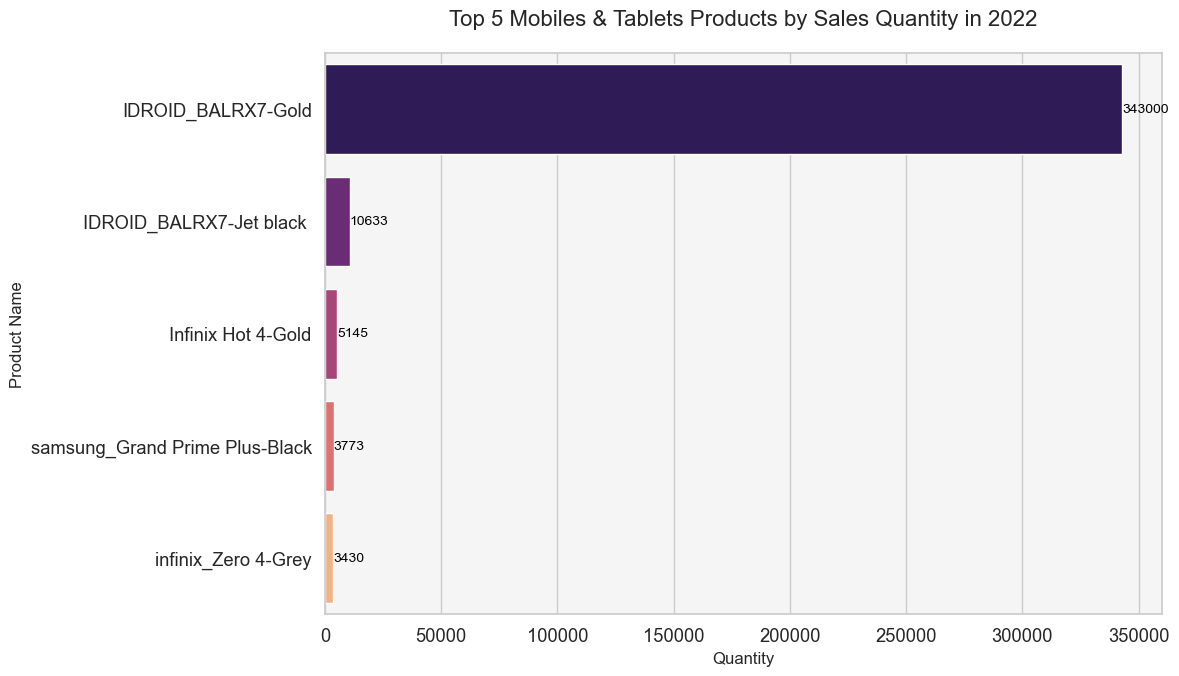

In [32]:
import seaborn as sns
import matplotlib.pyplot as plt
import os

# Set modern style
sns.set(style="whitegrid", font_scale=1.2, rc={"axes.facecolor": "#f5f5f5", "figure.facecolor": "#ffffff"})

# Plot horizontal bar chart
plt.figure(figsize=(12, 7))
bar_plot = sns.barplot(
    y='sku_name', 
    x='qty_ordered', 
    data=top_5_prod, 
    palette='magma'
)
plt.title('Top 5 Mobiles & Tablets Products by Sales Quantity in 2022', fontsize=16, pad=20)
plt.xlabel('Quantity', fontsize=12)
plt.ylabel('Product Name', fontsize=12)

# Add data labels on bars
for index, value in enumerate(top_5_prod['qty_ordered']):
    bar_plot.text(value + 50, index, f'{int(value)}', va='center', fontsize=10, color='black')

# Customize layout
plt.tight_layout()

# Save chart
output_folder = r"C:\Users\GODUGU SHASHANK\NullClass\Internship"
output_chart = os.path.join(output_folder, "task_1/top_5_mobiles_2022.png")
plt.savefig(output_chart, dpi=300, bbox_inches='tight')
plt.show()